# Kopi NangKau dengan Keputusan Berbasis Data

## [DATASET.CSV](https://drive.google.com/file/d/1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8/view?usp=sharing)

In [1]:
!gdown 1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8

Downloading...
From: https://drive.google.com/uc?id=1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8
To: /content/penjualan_kopi_2021_2023.csv
100% 232k/232k [00:00<00:00, 54.2MB/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Skenario:**

Diberikan data penjualan harian dari tahun 2021 hingga 2023. Data ini berisi penjualan berbagai produk minuman dan makanan di toko kopi NangKau.
Tugas kita disini adalah membersihkan, mengolah, dan menganalisis data penjualan supaya bisnis bisa terus berkembang.

---

### 💡 Informasi Dasar Harga Produk

| Produk      | Harga Dasar Tahun 2021 (Rp) |
|-------------|-----------------------------|
| Espresso    | 22.000                      |
| Latte       | 28.000                      |
| Cappuccino  | 25.000                      |
| Americano   | 21.000                      |
| Croissant   | 18.000                      |
| Donat       | 15.000                      |

- **Harga setiap produk naik 2% setiap tahun**  
  Contoh: Jika harga awal Espresso 22.000 di 2021, maka di 2023:  
  Tahun 2022 → 22.000 × 1.02 = 22.440  
  Tahun 2023 → 22.000 × 1.04 = 22.880 (pembulatan ke bawah karena integer di kode)

---
## Eksplorasi Data

1. Baca dataset ke pandas DataFrame.
2. Tampilkan 10 baris pertama.
3. Hitung jumlah baris, kolom, baris duplikat, serta missing value per kolom.
4. Pastikan Kolom Unit_Terjual dan Harga_Per_Unit

In [3]:
# 1. Baca dataset ke pandas DataFrame.
df = pd.read_csv('penjualan_kopi_2021_2023.csv', delimiter = ';', header = 0)

# 2. Tampilkan 10 baris pertama.
df.head(10)

,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52.0,21000.0
1,2021,Januari,1,Cappuccino,45.0,NaN
2,2021,Januari,1,Croissant,20.0,NaN
3,2021,Januari,1,Donat,20.0,15000.0
4,2021,Januari,1,Espresso,43.0,22000.0
5,2021,Januari,1,Latte,38.0,28000.0
6,2021,Januari,2,Americano,44.0,21000.0
7,2021,Januari,2,Cappuccino,36.0,NaN
8,2021,Januari,2,Croissant,18.0,18000.0
9,2021,Januari,2,Croissant,18.0,18000.0


In [4]:
# 3. Hitung jumlah baris, kolom, baris duplikat, serta missing value per kolom.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6600 non-null   int64  
 1   Bulan           6600 non-null   object 
 2   Tanggal         6600 non-null   int64  
 3   Produk          6100 non-null   object 
 4   Unit_Terjual    6100 non-null   float64
 5   Harga_Per_Unit  6100 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 309.5+ KB


In [5]:
# 4. Pastikan Kolom Unit_Terjual dan Harga_Per_Unit
print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print(f"Jumlah Missing Value:")
print(df.isnull().sum())

Jumlah Baris: 6600
Jumlah Kolom: 6
Jumlah Duplikat: 19
Jumlah Missing Value:
Tahun               0
Bulan               0
Tanggal             0
Produk            500
Unit_Terjual      500
Harga_Per_Unit    500
dtype: int64


### Temuan:
- Total Baris: 6.600

- Total Kolom: 6

- Baris Duplikat: 19 baris

- Ada 500 baris kosong (NaN) di kolom Produk, Unit_Terjual, dan Harga_Per_Unit.


---

## Data Cleaning & Imputasi

1. Untuk baris di mana **Produk kosong tapi Harga_Per_Unit ada**:  
   - Lengkapi nilai Produk dengan cara mencocokkan harga dan tahun pada daftar harga.
2. Untuk baris di mana **Harga_Per_Unit kosong tapi Produk ada**:  
   - Lengkapi Harga_Per_Unit berdasar produk dan tahun (lihat tabel harga & rumus kenaikan).
3. Untuk baris dengan **Produk & Harga_Per_Unit sama-sama kosong**, hapus baris tersebut.
4. Untuk **Unit_Terjual** yang kosong, langsung hapus baris.
5. Pastikan tidak ada nilai negatif di Unit_Terjual.
6. Hapus baris duplikat.

In [6]:
df

,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52.0,21000.0
1,2021,Januari,1,Cappuccino,45.0,NaN
2,2021,Januari,1,Croissant,20.0,NaN
3,2021,Januari,1,Donat,20.0,15000.0
4,2021,Januari,1,Espresso,43.0,22000.0
...,...,...,...,...,...,...
6595,2023,Desember,31,Cappuccino,51.0,26000.0
6596,2023,Desember,31,Croissant,NaN,18720.0
6597,2023,Desember,31,Espresso,39.0,22880.0
6598,2023,Desember,31,Latte,45.0,29120.0


In [7]:
### Membuat dictionary referensi untuk mengisi nilai kosong di tabel:
# 1. membuang row yang kosong dan duplikat agar akurat.

ref_product = df.dropna(subset=['Produk', 'Harga_Per_Unit']).drop_duplicates(subset=['Tahun', 'Harga_Per_Unit'])

# 2. Membuat mapping nama produk yang disesuaikan dengan harga dan tahun.

dict_product = ref_product.set_index(['Tahun', 'Harga_Per_Unit'])['Produk'].to_dict()

# 3. Mengisi nama produk yang kosong.

def nama_produk(row):
  if pd.isna(row['Produk']) and pd.notna(row['Harga_Per_Unit']):
    return dict_product.get((row['Tahun'], row['Harga_Per_Unit']), row['Produk'])
  else:
    return row['Produk']

# 4. Eksekusi

df['Produk'] = df.apply(nama_produk, axis = 1)
print(f"Apakah masih ada produk yang NULL tapi punya harga: {df[df['Produk'].isna() & df['Harga_Per_Unit'].notna()].shape[0]}")

df

Apakah masih ada produk yang NULL tapi punya harga: 0


,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52.0,21000.0
1,2021,Januari,1,Cappuccino,45.0,NaN
2,2021,Januari,1,Croissant,20.0,NaN
3,2021,Januari,1,Donat,20.0,15000.0
4,2021,Januari,1,Espresso,43.0,22000.0
...,...,...,...,...,...,...
6595,2023,Desember,31,Cappuccino,51.0,26000.0
6596,2023,Desember,31,Croissant,NaN,18720.0
6597,2023,Desember,31,Espresso,39.0,22880.0
6598,2023,Desember,31,Latte,45.0,29120.0


### Hal yang sama dilakukan untuk kolom harga:

In [8]:
### Membuat dictionary referensi untuk mengisi nilai kosong di tabel:
# 1. membuang row yang kosong dan duplikat agar akurat.

ref_product = df.dropna(subset=['Produk', 'Harga_Per_Unit']).drop_duplicates(subset=['Tahun', 'Produk'])

# 2. Membuat mapping nama produk yang disesuaikan dengan harga dan tahun.

dict_harga = ref_product.set_index(['Tahun', 'Produk'])['Harga_Per_Unit'].to_dict()

# 3. Mengisi nama produk yang kosong.

def harga_produk(row):
  if pd.isna(row['Harga_Per_Unit']) and pd.notna(row['Produk']):
    return dict_harga.get((row['Tahun'], row['Produk']), row['Harga_Per_Unit'])
  else:
    return row['Harga_Per_Unit']

# 4. Eksekusi

df['Harga_Per_Unit'] = df.apply(harga_produk, axis = 1)
print(f"Apakah masih ada produk yang memiliki harga NULL: {df[df['Harga_Per_Unit'].isna() & df['Produk'].notna()].shape[0]}")

df

Apakah masih ada produk yang memiliki harga NULL: 0


,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52.0,21000.0
1,2021,Januari,1,Cappuccino,45.0,25000.0
2,2021,Januari,1,Croissant,20.0,18000.0
3,2021,Januari,1,Donat,20.0,15000.0
4,2021,Januari,1,Espresso,43.0,22000.0
...,...,...,...,...,...,...
6595,2023,Desember,31,Cappuccino,51.0,26000.0
6596,2023,Desember,31,Croissant,NaN,18720.0
6597,2023,Desember,31,Espresso,39.0,22880.0
6598,2023,Desember,31,Latte,45.0,29120.0


In [9]:
# 3. Untuk baris dengan **Produk & Harga_Per_Unit sama-sama kosong**, hapus baris tersebut.
df = df.dropna(subset=['Produk', 'Harga_Per_Unit'], how = 'all')

# 4. Untuk **Unit_Terjual** yang kosong, langsung hapus baris.
df = df.dropna(subset=['Unit_Terjual'])

# 5. Pastikan tidak ada nilai negatif di Unit_Terjual.
#### Karena kita tidak tau berapa jumlah unit terjual yang negatif, kita cek dulu jumlahnya baru setelahnya memilih cara untuk mengatasinya
jumlah_negatif = (df['Unit_Terjual']<0).sum()
print(f"jumlah unit terjual yang bernilai negatif ada sebanyak: {jumlah_negatif}")

### Tidak ada unit yang negatif

# 6. Hapus baris duplikat.
df = df.drop_duplicates()

df

jumlah unit terjual yang bernilai negatif ada sebanyak: 0


,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52.0,21000.0
1,2021,Januari,1,Cappuccino,45.0,25000.0
2,2021,Januari,1,Croissant,20.0,18000.0
3,2021,Januari,1,Donat,20.0,15000.0
4,2021,Januari,1,Espresso,43.0,22000.0
...,...,...,...,...,...,...
6593,2023,Desember,30,Latte,51.0,29120.0
6594,2023,Desember,31,Americano,38.0,21840.0
6595,2023,Desember,31,Cappuccino,51.0,26000.0
6597,2023,Desember,31,Espresso,39.0,22880.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6041 entries, 0 to 6598
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6041 non-null   int64  
 1   Bulan           6041 non-null   object 
 2   Tanggal         6041 non-null   int64  
 3   Produk          6041 non-null   object 
 4   Unit_Terjual    6041 non-null   float64
 5   Harga_Per_Unit  6041 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 330.4+ KB


In [11]:
### Karena sebelumnya kolom Unit_Terjual dan Harga_Per_Unit sempat memiliki nilai kosong, maka tipe datanya menjadi Float. Jadi mari kebalikan agar menjadi Int
df['Unit_Terjual'] = df['Unit_Terjual'].astype(int)
df['Harga_Per_Unit'] = df['Harga_Per_Unit'].astype(int)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 6041 entries, 0 to 6598
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Tahun           6041 non-null   int64 
 1   Bulan           6041 non-null   object
 2   Tanggal         6041 non-null   int64 
 3   Produk          6041 non-null   object
 4   Unit_Terjual    6041 non-null   int64 
 5   Harga_Per_Unit  6041 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 330.4+ KB


,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit
0,2021,Januari,1,Americano,52,21000
1,2021,Januari,1,Cappuccino,45,25000
2,2021,Januari,1,Croissant,20,18000
3,2021,Januari,1,Donat,20,15000
4,2021,Januari,1,Espresso,43,22000
...,...,...,...,...,...,...
6593,2023,Desember,30,Latte,51,29120
6594,2023,Desember,31,Americano,38,21840
6595,2023,Desember,31,Cappuccino,51,26000
6597,2023,Desember,31,Espresso,39,22880


### Data Sudah Clean



---


## Feature Engineering

1. Buat kolom baru "Pendapatan".
2. Buat kolom "Tanggal_Penjualan" dengan format datetime.

In [12]:
# 1. Buat kolom baru "Pendapatan".
df['Pendapatan'] = df['Unit_Terjual'] * df['Harga_Per_Unit']

# 2. Buat kolom "Tanggal_Penjualan" with format datetime.
### Karena bulan dalam bahasa indonesia, kita buat dictionary terlebih dahulu

bulan_indonesia = {'Januari': 1, 'Februari': 2, 'Maret': 3, 'April': 4, 'Mei': 5, 'Juni': 6, 'Juli': 7, 'Agustus': 8, 'September': 9, 'Oktober': 10, 'November': 11, 'Desember': 12}

### kita bikin kolom sementara untuk mempermudah pengerjaan

df['bulan_sementara'] = df['Bulan'].map(bulan_indonesia)

### buat kolom "Tanggal Penjualan"

df['Tanggal_Penjualan'] = pd.to_datetime({'year': df['Tahun'], 'month': df['bulan_sementara'], 'day': df['Tanggal']})

### kita drop kolom sementara tadi karena sudah tidak dipakai
# Perbaikan: Jangan gunakan inplace=True saat melakukan assignment df = ...
df = df.drop(columns=['bulan_sementara'])

df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 6041 entries, 0 to 6598
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tahun              6041 non-null   int64         
 1   Bulan              6041 non-null   object        
 2   Tanggal            6041 non-null   int64         
 3   Produk             6041 non-null   object        
 4   Unit_Terjual       6041 non-null   int64         
 5   Harga_Per_Unit     6041 non-null   int64         
 6   Pendapatan         6041 non-null   int64         
 7   Tanggal_Penjualan  6041 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 424.8+ KB


,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit,Pendapatan,Tanggal_Penjualan
0,2021,Januari,1,Americano,52,21000,1092000,2021-01-01
1,2021,Januari,1,Cappuccino,45,25000,1125000,2021-01-01
2,2021,Januari,1,Croissant,20,18000,360000,2021-01-01
3,2021,Januari,1,Donat,20,15000,300000,2021-01-01
4,2021,Januari,1,Espresso,43,22000,946000,2021-01-01
...,...,...,...,...,...,...,...,...
6593,2023,Desember,30,Latte,51,29120,1485120,2023-12-30
6594,2023,Desember,31,Americano,38,21840,829920,2023-12-31
6595,2023,Desember,31,Cappuccino,51,26000,1326000,2023-12-31
6597,2023,Desember,31,Espresso,39,22880,892320,2023-12-31




---


## Analisis Grup & Visualisasi

1. Hitung total unit & pendapatan per produk.
2. Hitung rata-rata unit terjual per hari tiap produk pada tiap tahun.
3. Temukan produk terlaris per tahun.
4. Buat grafik batang total unit jual per produk (2021 - 2023).

In [13]:
df.head()

,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit,Pendapatan,Tanggal_Penjualan
0,2021,Januari,1,Americano,52,21000,1092000,2021-01-01
1,2021,Januari,1,Cappuccino,45,25000,1125000,2021-01-01
2,2021,Januari,1,Croissant,20,18000,360000,2021-01-01
3,2021,Januari,1,Donat,20,15000,300000,2021-01-01
4,2021,Januari,1,Espresso,43,22000,946000,2021-01-01


In [14]:
# Hitung total unit & pendapatan per produk.

total_unit = df.groupby('Produk')[['Unit_Terjual', 'Pendapatan']].sum()
total_unit.sort_values(by='Unit_Terjual', ascending=False)
total_unit.style.format({
    'Unit_Terjual': '{:,.0f}',
    'Pendapatan': 'Rp {:,.0f}'
})

,Unit_Terjual,Pendapatan
Produk,,
Americano,"39,265","Rp 840,748,020"
Cappuccino,"39,859","Rp 1,016,256,000"
Croissant,"21,360","Rp 392,115,960"
Donat,"22,379","Rp 342,290,700"
Espresso,"39,504","Rp 886,519,480"
Latte,"39,528","Rp 1,128,724,240"


In [15]:
# Hitung rata-rata unit terjual per hari tiap produk pada tiap tahun.


# kita gunakan unstack untuk memindahkan index Tahun ke kolom (horizontal)
# astype(int) agar rerata menjadi bulat kebawah, karena tidak mungkin terjual dalam bentuk desimal
rata_rata_terjual = df.groupby(['Produk', 'Tahun'])['Unit_Terjual'].mean().unstack().astype(int)
rata_rata_terjual

Tahun,2021,2022,2023
Produk,,,
Americano,40,38,38
Cappuccino,39,39,40
Croissant,21,21,20
Donat,22,22,21
Espresso,40,39,39
Latte,39,39,39


In [16]:
# Temukan produk terlaris per tahun.


Produk_Terlaris = df.groupby(['Tahun', 'Produk'])['Unit_Terjual'].sum().groupby('Tahun', group_keys=False).nlargest(1)
#nlargest(1): Di setiap halaman tahun tersebut, mencari 1 angka paling besar
#group_keys=False supaya tampilan akhirnya rapi dan tulisan Tahun-nya tidak tercetak double.
Produk_Terlaris

,,Unit_Terjual
Tahun,Produk,
2021,Americano,13504
2022,Cappuccino,13368
2023,Espresso,13248


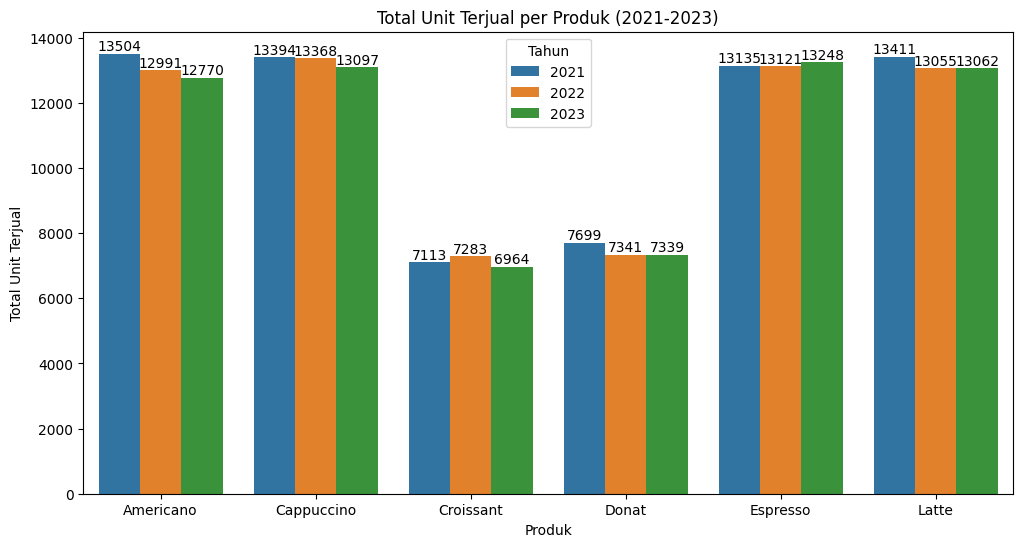

In [17]:
# Grafik batang total unit jual per produk (2021 - 2023).

datas = df.groupby(['Produk', 'Tahun'])['Unit_Terjual'].sum().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=datas, x='Produk', y='Unit_Terjual', hue='Tahun',  palette='tab10')
for c in ax.containers:
    ax.bar_label(c)

plt.title('Total Unit Terjual per Produk (2021-2023)')
plt.xlabel('Produk')
plt.ylabel('Total Unit Terjual')
plt.legend(title='Tahun')
plt.show()



---


## Rangkuman & Insight

## Temuan:
1. Selama periode tahun 2021 hingga 2023, kategori minuman kopi menyumbang volume penjualan terbesar dengan Cappuccino menjadi produk terlaris secara keseluruhan (39.859 unit), diikuti dengan ketat oleh Latte, Espresso, dan Americano yang semuanya stabil di angka 39.000-an unit.

2. Terdapat gap yang cukup jauh antara penjualan minuman dan makanan. Produk seperti Donat (22.418 unit) dan Croissant (21.360 unit) mencatatkan volume penjualan hampir setengah dari rata-rata penjualan minuman kopi.

3. Meskipun tren secara umum sangat stabil dari tahun ke tahun, terlihat ada sedikit penurunan permintaan pada produk Americano (dari 13.504 unit di 2021 menjadi 12.770 unit di 2023). Sebaliknya, Espresso menunjukkan sedikit tren positif di tengah penurunan produk lainnya (dari 13.135 unit di 2021 menjadi 13.248 unit di 2023).


## Rekomendasi Bisnis:
1. Buat paket promo bundling (misalnya potongan harga setiap pembelian makanan dan minuman tertentu"). Bertujuan agar pelanggan yang tadinya hanya membeli minuman agar bersedia mengeluarkan uang lebih untuk makanan, sehingga menaikkan rata-rata nilai transaksi per pelanggan.

2. Berdasarkan data yang menunjukkan tingginya permintaan pelanggan terhadap kategori kopi berbasis susu, maka bisa dioptimalkan potensi tersebut melalui pengembangan varian produk. Daripada mengalokasikan dana pada menu baru yang belum teruji pasarnya, lebih baik fokuskan pada lini produk yang telah memiliki basis permintaan yang kuat dan konsisten. Sebagai contoh, KopiNangkau dapat meluncurkan variasi rasa seperti Caramel Cappuccino atau Hazelnut Latte untuk meningkatkan daya tarik tanpa harus merombak struktur menu utama yang sudah terbukti profitabilitasnya.

3. Berdasarkan data. dapat dilihat bahwa penggemar Espresso di kafe ini terbukti sangat stabil dan setia. Meskipun dengan perubahan harga dan tren, mereka tetap rutin untuk membeli Espresso. jadi, misalnya harga bahan baku lagi naik dan kafe terpaksa harus menaikkan harga jual, menu Espresso adalah pilihan paling aman buat dinaikkan sedikit harganya. ini merupakan langkah yang secara statistik paling aman dan minim risiko kehilangan pelanggan.

##



1. **Identifikasi Bulan Tertinggi dan Terendah**
   
   - Temukan bulan dan tahun dengan total penjualan unit tertinggi dan terendah (dalam seluruh periode).
   - Visualisasikan trennya (misal line chart penjualan bulanan).

Bulan dan Tahun dengan Total Penjualan Tertinggi:

 Tahun Bulan  Unit_Terjual  Bulan_Angka
  2022 Maret          6024            3

Bulan dan Tahun dengan Total Penjualan Terendah
:
 Tahun    Bulan  Unit_Terjual  Bulan_Angka
  2022 Februari          5011            2


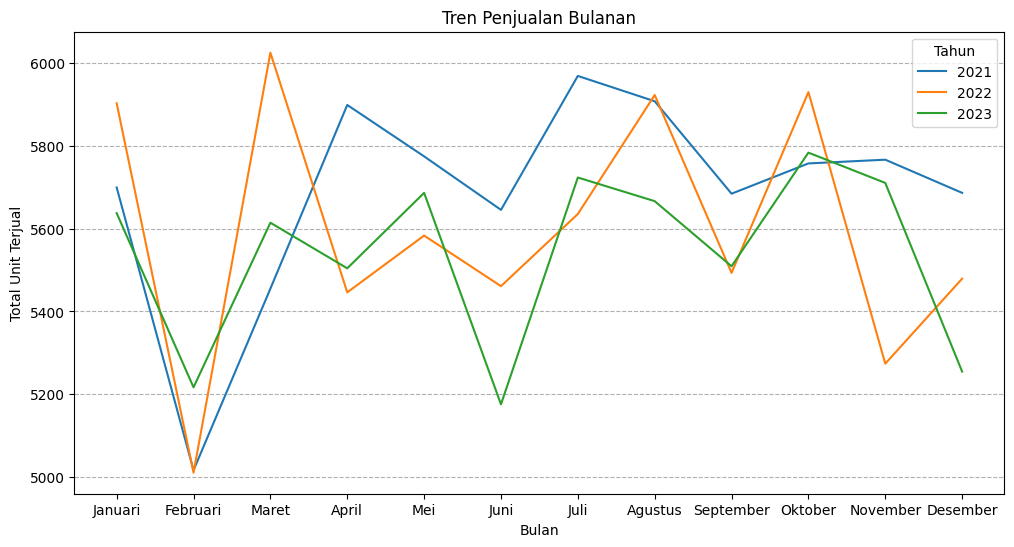

In [18]:
from matplotlib.lines import lineStyles
# 1. Identifikasi Bulan Tertinggi dan Terendah

# Temukan bulan dan tahun dengan total penjualan unit tertinggi dan terendah (dalam seluruh periode).
Penjualan = df.groupby(['Tahun', 'Bulan']).agg({'Unit_Terjual': 'sum'}).reset_index()
Penjualan['Bulan_Angka'] = Penjualan['Bulan'].map(bulan_indonesia)
Penjualan = Penjualan.sort_values(['Tahun', 'Bulan_Angka'])
sort_penjualan = Penjualan.sort_values(by='Unit_Terjual', ascending=False)
print("Bulan dan Tahun dengan Total Penjualan Tertinggi:\n")
print(sort_penjualan.head(1).to_string(index=False))
print("\nBulan dan Tahun dengan Total Penjualan Terendah\n:")
print(sort_penjualan.tail(1).to_string(index=False))

# Visualisasikan trennya (misal line chart penjualan bulanan).
plt.figure(figsize=(12,6))
ax = sns.lineplot(data=Penjualan, x='Bulan', y='Unit_Terjual', hue='Tahun', palette='tab10')

plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Unit Terjual')
plt.grid(axis='y', linestyle='--')
plt.legend(title='Tahun')
plt.show()

2. **Analisis Pertumbuhan Penjualan**
   
   - Bandingkan total penjualan (unit terjual maupun pendapatan) antar tahun 2021, 2022, dan 2023.
   - Produk apa yang pertumbuhannya paling tinggi selama 3 tahun?
   - Tampilkan hasilnya dalam bentuk tabel ringkasan pertumbuhan dan/atau visualisasi sederhana.

In [19]:
# Bandingkan total penjualan (unit terjual maupun pendapatan) antar tahun 2021, 2022, dan 2023.
total_penjualan = df.groupby('Tahun')[['Unit_Terjual', 'Pendapatan']].sum()
total_penjualan


,Unit_Terjual,Pendapatan
Tahun,,
2021,68256,1526431000
2022,67159,1532470440
2023,66480,1547752960


In [20]:
# Produk apa yang pertumbuhannya paling tinggi selama 3 tahun?
pertumbuhan_produk = df.groupby(['Tahun', 'Produk'])['Unit_Terjual'].sum().unstack(level=0)

# Hitung persentase pertumbuhan dari 2021 ke 2023
pertumbuhan_produk['Pertumbuhan (2022 - 2021)'] = ((pertumbuhan_produk[2022] - pertumbuhan_produk[2021]) / pertumbuhan_produk[2021]) * 100
pertumbuhan_produk['Pertumbuhan (2023 - 2022)'] = ((pertumbuhan_produk[2023] - pertumbuhan_produk[2022]) / pertumbuhan_produk[2022]) * 100
pertumbuhan_produk['Pertumbuhan (2023 - 2021)'] = ((pertumbuhan_produk[2023] - pertumbuhan_produk[2021]) / pertumbuhan_produk[2021]) * 100
pertumbuhan_produk

Tahun,2021,2022,2023,Pertumbuhan (2022 - 2021),Pertumbuhan (2023 - 2022),Pertumbuhan (2023 - 2021)
Produk,,,,,,
Americano,13504,12991,12770,-3.798874,-1.701178,-5.435427
Cappuccino,13394,13368,13097,-0.194117,-2.027229,-2.217411
Croissant,7113,7283,6964,2.389990,-4.380063,-2.094756
Donat,7699,7341,7339,-4.649955,-0.027244,-4.675932
Espresso,13135,13121,13248,-0.106585,0.967914,0.860297
Latte,13411,13055,13062,-2.654537,0.053619,-2.602341


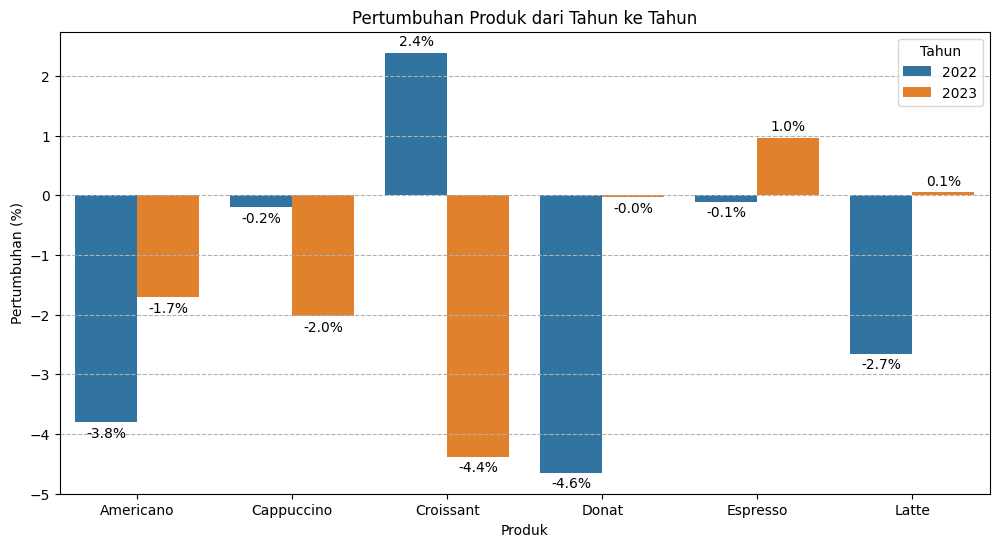

In [21]:
# Tampilkan hasilnya dalam bentuk visualisasi sederhana.
pivot_penjualan = df.pivot_table(index='Produk', columns='Tahun', values='Unit_Terjual', aggfunc='sum')
pertumbuhan = pivot_penjualan.pct_change(axis=1) * 100
pertumbuhan = pertumbuhan.drop(columns=2021)
pertumbuhan = pertumbuhan.reset_index().melt(id_vars='Produk', var_name='Tahun', value_name='Pertumbuhan')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pertumbuhan, x='Produk', y='Pertumbuhan', hue='Tahun', palette='tab10')
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', padding=3)
plt.title('Pertumbuhan Produk dari Tahun ke Tahun')
plt.xlabel('Produk')
plt.ylabel('Pertumbuhan (%)')
plt.grid(axis='y', linestyle='--')
plt.legend(title='Tahun')
plt.show()

3. **Simulasi Promo Diskon**

   - Simulasikan jika ada diskon 10% untuk produk minuman di bulan-bulan tertentu (misal: Juli & Agustus), dan asumsikan penjualan produk-produk ini naik 15% di bulan promo.
   - Hitung dan bandingkan pendapatan asli vs pendapatan setelah promo.
   - insight-nya, apakah strategi promo ini efektif?


In [22]:
# Simulasi Promo Diskon

minuman = ['Americano', 'Cappuccino', 'Espresso', 'Latte']
bulan_promo = ['Juli', 'Agustus']

simulasi = df.copy()

promo = (simulasi['Produk'].isin(minuman)) & (simulasi['Bulan'].isin(bulan_promo))

# asumsi: Unit terjual naik 15% dan Harga turun 10% (diskon)
simulasi.loc[promo, 'Unit_Terjual'] = (simulasi.loc[promo, 'Unit_Terjual'] * 1.15).astype(int)
simulasi.loc[promo, 'Harga_Per_Unit'] = (simulasi.loc[promo, 'Harga_Per_Unit'] * 0.9).astype(int)

simulasi['Pendapatan_Simulasi'] = simulasi['Unit_Terjual'] * simulasi['Harga_Per_Unit']

# Perbandingan Total Pendapatan
total_asli = df['Pendapatan'].sum()
total_promo = simulasi['Pendapatan_Simulasi'].sum()


## Hitung dan bandingkan pendapatan asli vs pendapatan setelah promo.
print(f"Total Pendapatan Asli: Rp {total_asli:,.0f}")
print(f"Total Pendapatan Setelah Simulasi Promo: Rp {total_promo:,.0f}")
print(f"Selisih: Rp {total_promo - total_asli:,.0f}")
print(f"Persentase Perubahan: {((total_promo - total_asli) / total_asli) * 100:.2f}%")

Total Pendapatan Asli: Rp 4,606,654,400
Total Pendapatan Setelah Simulasi Promo: Rp 4,622,926,390
Selisih: Rp 16,271,990
Persentase Perubahan: 0.35%


#### Jelaskan insight-nya, apakah strategi promo ini efektif?
Dari total perputaran uang sebesar Rp 4,6 Miliar, tambahan Rp 16,2 Juta itu sangat kecil (hanya 0.35%). Pelanggan mungkin senang mendapat diskon 10%, namun dampak finansialnya bagi skala perusahaan hampir tidak terasa. Diskon baru bisa dikatakan sukses jika ia mampu memicu lonjakan pendapatan minimal diatas angka 5%.

Jika kita lihat 15% kenaikan penjualan:
- mengorbankan harga turun 10%.
- modal ekstra sebesar 15% untuk membeli lebih banyak bahan baku
- membayar tambahan barista untuk mengejar target dan lonjakan pelanggan
- Tambahan pendapatan 16jt tadi kemungkinan besar akan habis tergerus oleh biaya lain untuk mengejar penjualan 15%

Simulasi menurunkan harga kopi sebesar 10% ternyata hanya menarik pelanggan membeli 15% lebih banyak, Tapi orang yang tidak biasa minum kopi juga logikanya tidak akan tiba-tiba membeli banyak kopi hanya karena harganya turun 10%.


### **Solusinya**
Jangan berikan diskon secara cuma-cuma. Berikan syarat seperti: "Diskon 15% untuk pembelian minimum 3 gelas." Ini memaksa pelanggan yang datang sendirian untuk mengajak temannya. Jadi jika dia hanya membeli 1 gelas, dia tidak dapat potongan yang memberatkan kafe, tapi jika mereka membeli minimal 3 gelas maka itu akan melonjak penjualan.

jangan diskon kopinya karena peminatnya sudah pasti banyak sesuai dengan analisis sebelumnya, tapi berikan diskon yang masuk akal untuk donat atau croissant jika dibeli bersama kopi.

4. **Deteksi Outlier**
   
   - Temukan hari-hari/tanggal tertentu dimana penjualan produk “melonjak tidak wajar” (misal, tiga kali lipat dari median hariannya).
   - Buat list tanggal tersebut dan sebutkan produk apa saja yang menjadi “outlier”.
   - Akan lebih baik jika langsung ditampilkan dalam bentuk boxplot



In [23]:
# Temukan hari-hari/tanggal tertentu dimana penjualan produk “melonjak tidak wajar”
melonjak = df.groupby(['Tanggal_Penjualan'], as_index=False)['Unit_Terjual'].sum()
melonjak

,Tanggal_Penjualan,Unit_Terjual
0,2021-01-01,218
1,2021-01-02,214
2,2021-01-03,163
3,2021-01-04,153
4,2021-01-05,184
...,...,...
1090,2023-12-27,126
1091,2023-12-28,135
1092,2023-12-29,193
1093,2023-12-30,236


In [24]:
# Quartile
Q1 = melonjak['Unit_Terjual'].quantile(0.25)
Q3 = melonjak['Unit_Terjual'].quantile(0.75)

# IQR
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

lonjakan = melonjak[melonjak['Unit_Terjual'] > batas_atas]

print(f"Batas Penjualan Wajar Maksimal adalah: {int(batas_atas):,} Unit/Hari\n")
print("DAFTAR HARI DENGAN LONJAKAN TIDAK WAJAR:")
print(lonjakan[['Tanggal_Penjualan', 'Unit_Terjual']].to_string(index=False))

Batas Penjualan Wajar Maksimal adalah: 266 Unit/Hari

DAFTAR HARI DENGAN LONJAKAN TIDAK WAJAR:
Tanggal_Penjualan  Unit_Terjual
       2021-09-07           269


In [25]:
# List Produk yang menjadi outlier
def cari_outlier(group):
    Q1 = group['Unit_Terjual'].quantile(0.25)
    Q3 = group['Unit_Terjual'].quantile(0.75)
    IQR = Q3 - Q1
    batas_atas = Q3 + 1.5 * IQR
    return group[group['Unit_Terjual'] > batas_atas]

outlier = df.groupby('Produk').apply(cari_outlier).reset_index(drop=True)
outlier = outlier.sort_values(by=['Tahun', 'Bulan', 'Tanggal'], ascending=False)
outlier

print("DAFTAR PRODUK DAN TANGGAL LONJAKAN TIDAK WAJAR:")
if not outlier.empty:
    print(outlier[['Tanggal_Penjualan', 'Produk', 'Unit_Terjual']].to_string(index=False))
else:
    print("Tidak ditemukan lonjakan yang melewati batas statistik IQR.")

DAFTAR PRODUK DAN TANGGAL LONJAKAN TIDAK WAJAR:
Tanggal_Penjualan     Produk  Unit_Terjual
       2023-09-02 Cappuccino            63
       2023-11-25 Cappuccino            62
       2023-05-21  Croissant            45
       2023-03-09 Cappuccino            62
       2023-04-13      Donat            46
       2023-08-25   Espresso            64
       2023-08-04  Americano            62
       2022-09-12 Cappuccino            65
       2022-10-26  Croissant            47
       2022-11-06  Americano            62
       2022-06-25      Latte            62
       2022-01-20      Latte            64
       2022-02-25      Latte            63
       2022-02-22  Croissant            45
       2022-04-28  Americano            71
       2022-04-12      Donat            43
       2021-09-27      Latte            65
       2021-11-23      Latte            65
       2021-05-06      Donat            43
       2021-03-21  Croissant            46
       2021-01-30      Donat            43
      

/tmp/ipykernel_5031/2279970829.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier = df.groupby('Produk').apply(cari_outlier).reset_index(drop=True)


/tmp/ipykernel_5031/2343683022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Produk', y='Unit_Terjual', palette='pastel')


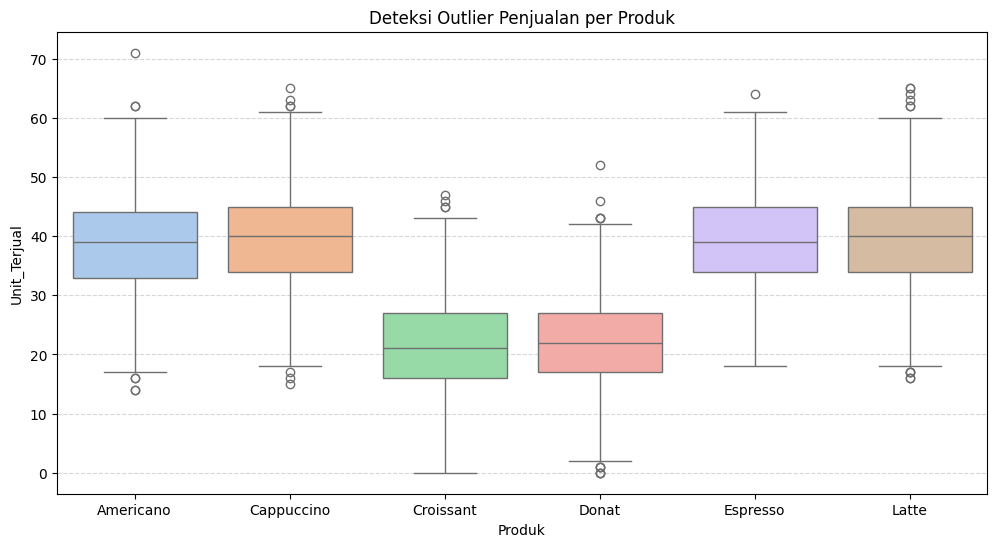

In [26]:
# Visualisasi dengan Boxplot untuk melihat sebaran outlier
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Produk', y='Unit_Terjual', palette='pastel')

plt.title('Deteksi Outlier Penjualan per Produk')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

5. **Cek Konsistensi Harga**
   
   - Adakah harga produk yang tidak sesuai aturan/rumus kenaikan 2% per tahun? (Cek kolom Harga_Per_Unit)
   - Jika ada data yang tidak konsisten, tampilkan semua kasusnya dan buat analisa ringkas.
  

In [27]:
# Adakah harga produk yang tidak sesuai aturan/rumus kenaikan 2% per tahun? (Cek kolom Harga_Per_Unit)

cek_aturan = df.drop_duplicates(subset=['Tahun', 'Produk', 'Harga_Per_Unit']).copy()

harga_dasar = {
    'Americano': 21000,
    'Cappuccino': 25000,
    'Croissant': 18000,
    'Donat': 15000,
    'Espresso': 22000,
    'Latte': 28000
}

def hitung_ekspektasi(row):
    base = harga_dasar.get(row['Produk'])
    if row['Tahun'] == 2021: return base
    if row['Tahun'] == 2022: return int(base * 1.02)
    if row['Tahun'] == 2023: return int(base * 1.04)
    return None

cek_aturan['Harga_Ekspektasi'] = cek_aturan.apply(hitung_ekspektasi, axis=1)

# Filter data yang tidak konsisten
inkonsisten = cek_aturan[cek_aturan['Harga_Per_Unit'] != cek_aturan['Harga_Ekspektasi']]

if inkonsisten.empty:
    print("Hasil: Semua harga produk konsisten dengan aturan kenaikan 2% per tahun.")
else:
    print(f"Hasil: Ditemukan {len(inkonsisten)} data harga yang tidak konsisten!")
    display(inkonsisten[['Tahun', 'Produk', 'Harga_Per_Unit', 'Harga_Ekspektasi']])

Hasil: Semua harga produk konsisten dengan aturan kenaikan 2% per tahun.
